In [5]:
import sys
from pathlib import Path
import pandas as pd

# allow importing from src
root = Path("../../../").resolve()
sys.path.append(str(root / "src"))

from rice_ml.supervised_learning.k_nearest_neighbors import (
    train_knn_model,
    evaluate_knn_model,
)

df = pd.read_csv("../../../datasets/census_income.csv")

model, X_train, X_test, y_train, y_test, cat_cols, num_cols = train_knn_model(
    df,
    target_col="income",
    n_neighbors=5,
)

metrics = evaluate_knn_model(model, X_test, y_test)


Accuracy: 0.8290510799467704
Confusion Matrix:
 [[6729  685]
 [ 985 1370]]
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      7414
        >50K       0.67      0.58      0.62      2355

    accuracy                           0.83      9769
   macro avg       0.77      0.74      0.76      9769
weighted avg       0.82      0.83      0.82      9769



**Please Refer to README for explaination of results**

In [14]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\mritu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:

!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


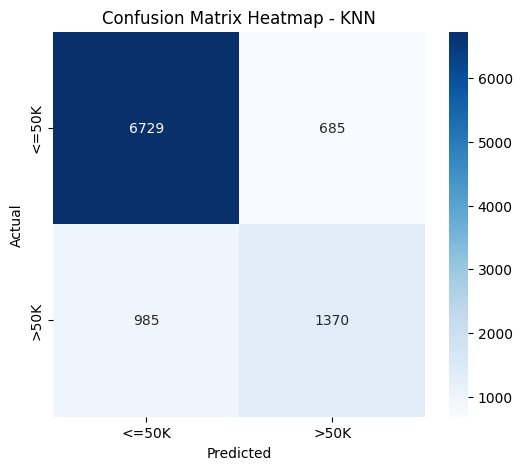

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

preds = model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap - KNN")
plt.show()
